<table>
    <tr>
      <td>Minería de datos y Paradigma BigData (<b>MIN</b>)- Facultad de Informática - UCM
      </td>
      <td>
      <img src="https://biblioteca.ucm.es/data/cont/media/www/pag-88746//escudo.jpg"  width=50/>
      </td>
     </tr>
</table>




### Práctica 5: Preprocesamiento Fútbol

Pablo C. Cañizares


Has recibido una llamada de una conocida compañía de fútbol electónico, te necesitan como analista de datos para tomar decisiones. 
Los campos del *dataset* a analizar son los siguientes:

| Variable       | Descripción (castellano)                                                                            | Ejemplo               |
| -------------- | --------------------------------------------------------------------------------------------------- | --------------------- |
| **Ratings**    | Puntuación global de la carta (0 – 99).                                                             | 92                    |
| **Position**   | Posición principal del jugador en el campo (por ej., POR, DC, MC).                                  | DC                    |
| **Version**    | Tipo o edición de la carta (Oro, TOTW, TOTY, Flashback, etc.).                                      | TOTY                  |
| **Price**         | Precio en el mercado de PlayStation; **0** indica que no está disponible.                           | 550 000               |
| **SKI**        | Estrellas de filigranas (0 – 5).                                                                    | 5                     |
| **WF**         | Estrellas de pierna mala (0 – 5).                                                                   | 4                     |
| **WR**         | Ritmo de trabajo ataque/defensa; cada valor puede ser *bajo*, *medio* o *alto* (ej.: alto / medio). | alto / medio          |
| **PAC**        | Ritmo (velocidad).                                                                                  | 93                    |
| **SHO**        | Disparo (potencia y precisión de tiro).                                                             | 89                    |
| **PAS**        | Pase.                                                                                               | 91                    |
| **DRI**        | Regate.                                                                                             | 94                    |
| **DEF**        | Defensa.                                                                                            | 45                    |
| **PHY**        | Fuerza física.                                                                                      | 78                    |
| **Body**       | Altura en cm y pies + tipo de complexión del jugador + peso.            | 182 cm / 6'0" — Única |
| **Popularity** | Índice de popularidad de uso entre la comunidad.                                                    | 87                    |
| **BS**         | Suma de estadísticas base (*Base Stats*).                                                           | 495                   |
| **IGS**        | Suma de estadísticas “en partido” (*In-Game Stats*).                                                | 2 300                 |



Antes de arrancar la experiencia, vamos a instalar módulos nuevos

In [1]:
modules = ["numpy", "pandas", "matplotlib", "scikit-learn", "beautifulsoup4", "pprint", "seaborn"]

import sys
import os.path
from subprocess import check_call
import importlib
import os

def instala(modules):
    print("Instalando módulos")
    for m in modules:
        # para el import quitamos [...] y ==...
        p = m.find("[")
        mi = m if p==-1 else m[:p]
        p = mi.find("==")
        mi = mi if p==-1 else mi[:p]
        torch_loader = importlib.util.find_spec(mi)
        if torch_loader is not None:
            print(m," encontrado")
        else:
            print(m," No encontrado, instalando...",end="")  
            try:        
                r = check_call([sys.executable, "-m", "pip", "install", "--user", m])
                print("¡hecho!")
            except:
                print("¡Problema al instalar ",m,"! ¿seguro que el módulo existe?",sep="")

    print("¡Terminado!")

instala(modules)  

Instalando módulos
numpy  encontrado
pandas  encontrado
matplotlib  encontrado
scikit-learn  No encontrado, instalando...¡hecho!
beautifulsoup4  No encontrado, instalando...¡hecho!
pprint  encontrado
seaborn  encontrado
¡Terminado!


---------------------

## Iniciamos cargando los dataframes

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import seaborn as sns

original = pd.read_csv("analista_futbol.csv") 
modificado=pd.read_csv("analista_modificado.csv")
df_main = original.copy()

df_main.head()

,Name,RAT,POS,VER,Price,SKI,WF,WR,PAC,SHO,PAS,DRI,DEF,PHY,Body,Popularity,BS,IGS
0,Pelé,99,"LW RM,LM,RW",Shapeshifters ICON Explosive,2.88M,5,5,H \ M,96,97,94,99,61,78,"173cm | 5'8"" Unique (70kg)",3080,525,2557
1,Kevin De Bruyne,99,CM CAM,Level Up Obj Controlled,0,5,5,H \ H,88,95,99,97,91,99,"181cm | 5'11"" Unique (70kg)",1048,569,2743
2,Cristiano Ronaldo,99,"ST CF,LW",Futties Premium Controlled,9.8M,5,5,H \ L,97,99,93,97,41,88,"187cm | 6'2"" CR7 (83kg)",4143,515,2499
3,Lionel Messi,99,"ST RM,RW",Futties Premium Controlled,5.95M,5,5,H \ L,95,98,99,99,41,81,"169cm | 5'7"" Messi (67kg)",2757,513,2506
4,Neymar Jr,99,"CAM LM,LW",Futties Explosive,0,5,5,H \ M,99,96,95,99,50,78,"175cm | 5'9"" Neymar (68kg)",1335,517,2531


---

### **Ejercicio 1** (3 puntos) 
Implementa una función *modifica* que dado un dataframe (ya cargado), realice operaciones de manejo de columnnas y variables.
Realiza las siguientes operaciones: 

- Haz una función que convierta la columna Body en dos columnas: *Weigth* y *Height*, en centímetros y kilogramos respectivamente. Las columnas deben ser del tipo numerico. Al terminar, asegúrate de eliminar la columna *Body*.
- Haz una función que gestione la columna *POS*, y se quede únicamente el primer resultado de la lista. Es decir, si inicialmente tiene *LW RM,LM,R*, únicamente se debe quedar con *LW*.  Al terminar, asegúrate de eliminar la columna *POS*.
- Haz una función que gestione la columna *WR*, y genere dos columnas: *AttackWorkRate* y *DefenseWorkRate*, los valores se obtienen de los operandos contenidos en la columna. La columna tiene valores en formato *X\Y* (ej. 'H \ M'), el primero sería *AttackWorkRate* y el segundo *DefenseWorkRate*. Elimina la columna *WR*.

Recordatorio: Para aplicar una función a un dataframe se utiliza [`apply`](https://pandas.pydata.org/pandas-docs/dev/reference/api/pandas.DataFrame.apply.html)

In [103]:
#solución            
import pandas as pd

def f1(df):
    df_ret = df.copy()

    # Guardamos los valores de Body en una nueva columna
    df_ret['Weight'] = df_ret['Body'].apply(
        lambda x: float(x.split('(')[-1].split('kg)')[0].strip()) if isinstance(x, str) and 'kg)' in x else np.nan
    )

    df_ret['Height'] = df_ret['Body'].apply(
        lambda x: int(x.split('cm')[0].strip()) if isinstance(x, str) and 'cm' in x else np.nan
    )
   
    
    # Eliminamos la columna Body
    df_ret = df_ret.drop(columns=['Body'])
   
    return df_ret


def f2(df):
    df_ret = df.copy()

    df_ret['Pos'] = df_ret['POS'].apply(lambda x: x.split()[0].strip())

    # Eliminamos la columna POS
    df_ret = df_ret.drop(columns=['POS'])
   
    return df_ret


def f3(df):
    df_ret = df.copy()

    # Separamos usando el carácter '\'
    df_ret['AttackWorkRate'] = df_ret['WR'].apply(lambda x: x.split('\\')[0].strip())
    df_ret['DefenseWorkRate'] = df_ret['WR'].apply(lambda x: x.split('\\')[1].strip())

    # Eliminamos la columna WR
    df_ret = df_ret.drop(columns=['WR'])
   
    return df_ret


def modifica(df):
    #...
    df_ret = df.copy()
    df_ret = f1(df_ret)
    df_ret = f2(df_ret)
    df_ret = f3(df_ret)

    return df_ret

In [104]:
#Para probarlo ...
df_mod = modifica(df_main)
df_mod.head()

,Name,RAT,VER,Price,SKI,WF,PAC,SHO,PAS,DRI,DEF,PHY,Popularity,BS,IGS,Weight,Height,Pos,AttackWorkRate,DefenseWorkRate
0,Pelé,99,Shapeshifters ICON Explosive,2.88M,5,5,96,97,94,99,61,78,3080,525,2557,70.0,173,LW,H,M
1,Kevin De Bruyne,99,Level Up Obj Controlled,0,5,5,88,95,99,97,91,99,1048,569,2743,70.0,181,CM,H,H
2,Cristiano Ronaldo,99,Futties Premium Controlled,9.8M,5,5,97,99,93,97,41,88,4143,515,2499,83.0,187,ST,H,L
3,Lionel Messi,99,Futties Premium Controlled,5.95M,5,5,95,98,99,99,41,81,2757,513,2506,67.0,169,ST,H,L
4,Neymar Jr,99,Futties Explosive,0,5,5,99,96,95,99,50,78,1335,517,2531,68.0,175,CAM,H,M


#### **Ejercicio** 2 (1 punto) - Implementa una función *matriz_correlacion*.
Dado un dataframe (ya cargado) muestra su matriz de correlación en modo gráfico.

In [105]:
def matriz_correlacion(df, name):
    #solución
    # Seleccionar solo variables numéricas
    df_num = df.select_dtypes(include=['number'])
   
    # Calcular matriz de correlación
    correlaciones = df_num.corr()
   
    # Crear figura
    plt.figure(figsize=(11,8))
   
    # Dibujar mapa de calor
    sns.heatmap(correlaciones, cmap="coolwarm", annot=True, fmt=".2f", square=True, cbar=True)
   
    # Título
    plt.title(f"Correlación Variables Numéricas de: {name}")
    plt.show()


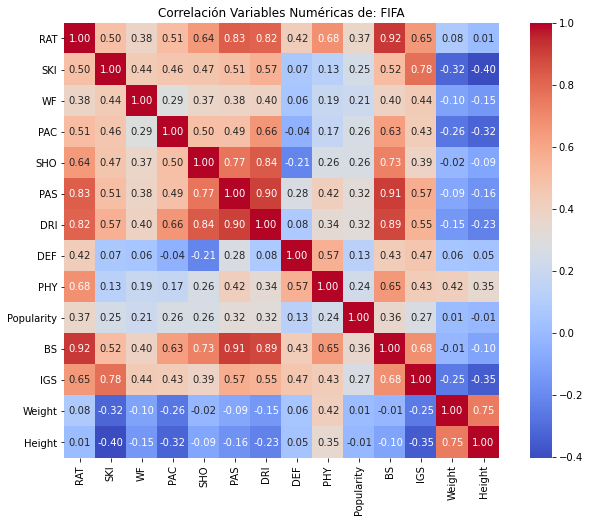

In [106]:
#Para probarlo ...
matriz_correlacion(df_mod, "FIFA")

¿Qué variables consideras que son redundantes? ¿Se podrían eliminar?

---
### **Ejercicio** 3 - (3 puntos). Implementa una función *transforma_categóricas*.
Dado un dataframe (ya cargado) transforma las variables categoricas del dataframe (puedes descartar 'Name'), tal como hemos visto en clase. Finalmente el dataframe debe ser retornado al usuario. 

In [107]:
#solución
def transforma_categoricas(df):
    df_catRet = df.copy()    
    
    # Seleccionamos columnas catgoricas
    columnas_categoricas = df_catRet.select_dtypes(include=['object']).columns
    
    # Aplica One-Hot Encoding para transformar las variables categóricas en nºs binarios
    df_catRet = pd.get_dummies(df_catRet, columns=columnas_categoricas, drop_first=True)
    
    return df_catRet

Justifica el método que has utilizado para realizar la transformación y las variables transformadas.

Método utilizado: One-Hot Encoding

Para transformar variables categóricas (tipo object) en variables numéricas, usamos pd.get_dummies().

Esto se llama One-Hot Encoding: cada categoría se convierte en una columna binaria. De esta forma, tenemos tantas columnas como

Variables transformadas:
-Las columnas categoricas se convierten a binarias para que sea más facil el procesarlas


In [108]:
#Para probar
df_trans = transforma_categoricas(df_mod);
df_trans.head()

,RAT,SKI,WF,PAC,SHO,PAS,DRI,DEF,PHY,Popularity,...,Pos_LWB,Pos_RB,Pos_RM,Pos_RW,Pos_RWB,Pos_ST,AttackWorkRate_L,AttackWorkRate_M,DefenseWorkRate_L,DefenseWorkRate_M
0,99,5,5,96,97,94,99,61,78,3080,...,0,0,0,0,0,0,0,0,0,1
1,99,5,5,88,95,99,97,91,99,1048,...,0,0,0,0,0,0,0,0,0,0
2,99,5,5,97,99,93,97,41,88,4143,...,0,0,0,0,0,1,0,0,1,0
3,99,5,5,95,98,99,99,41,81,2757,...,0,0,0,0,0,1,0,0,1,0
4,99,5,5,99,96,95,99,50,78,1335,...,0,0,0,0,0,0,0,0,0,1


---

### **Ejercicio 4** (1 punto). Central dominante. 

Análisis comparativo. Una vez preprocesado el dataset, será necesario implementar las consultas necesarias para marcar la diferencia en el mercado de fichajes.

Queremos encontrar al defensa central más dominante que cumpla las siguientes características: 
 - Juega en la posición *CB*
 - PHY >= 85
 - DEF >= 85
 - Altura >= 185
 - Ratings >= 87

Además de cumplir las características anteriores, se quiere medir con el índice de fuerza-defensa-popularidad. El cual se calcula sumando esas tres características del jugador. Haz una lista de los 3 mejores defensas centrales (invoca en un dataframe el método [**sort_values**](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html)) que reúnan todas estas características y ordenalos por el índice descrito.

In [109]:
#Solución
print(df_mod['Pos'].unique())

# Filtro de defensas centrales muy físicos
df_dc = df_mod[
    (df_mod['Pos'] == 'CB') &
    (df_mod['PHY'] >= 85) &
    (df_mod['DEF'] >= 85) &
    (df_mod['Height'] >= 185) &
    (df_mod['RAT'] >= 87)
].copy()

# Creamos índice combinado de dominio
df_dc['Indice_Fuerza_Defensa'] = df_dc['PHY'] + df_dc['DEF'] + df_dc['Popularity']

# Ordenamos y mostramos el top 3
df_dc_sorted = df_dc.sort_values(by='Indice_Fuerza_Defensa', ascending=False)

#Imprimimos y probamos
print(df_dc_sorted[['Name', 'Pos', 'RAT', 'PHY', 'DEF', 'Popularity', 'Weight', 'Indice_Fuerza_Defensa']].head(10))


['LW' 'CM' 'ST' 'CAM' 'CF' 'GK' 'CDM' 'RM' 'RW' 'CB' 'LB' 'LM' 'RB' 'RWB'
 'LWB']
                           Name Pos  RAT  PHY  DEF  Popularity  Weight  \
908            Leonardo Bonucci  CB   90   87   92        9518    85.0   
742            Presnel Kimpembe  CB   91   94   91        5092    80.0   
815             Virgil van Dijk  CB   90   86   91        4586    92.0   
1599                Eric Bailly  CB   87   88   87        4108    77.0   
556             Aymeric Laporte  CB   92   90   93        3950    85.0   
1349             Chris Smalling  CB   88   89   87        3933    81.0   
427            Gianluigi Buffon  CB   93   93   96        3366    92.0   
1101                John Stones  CB   89   87   90        3164    76.0   
544               Ronald Araujo  CB   92   92   92        2867    91.0   
1029  Lucimar da Silva Ferreira  CB   89   89   91        2774    84.0   

      Indice_Fuerza_Defensa  
908                    9697  
742                    5277  
815          

---
### **Ejercicio 5** (1 punto). Lista de los mejores jugadores calidad/precio.

Completa la función **mejor_calidad_precio** para que calcule la lista de los mejores jugadores de una `posición` atendiendo a su ratio  su `calidad` / `precio`, y una popularidad mínima (5000). 

PD: Es posible que si no has convertido alguna columna previamente, tengas que hacerlo ahora.

In [110]:
#Solución
# Funcion auxiliar para parsear los precios
def parse_precio_aux(p):
    p = str(p).upper().strip()
    if 'M' in p:
        return float(p.replace('M', '')) * 1000000
    elif 'K' in p:
        return float(p.replace('K', '')) * 1000
    else:
        return float(p)

def mejor_calidad_precio(df, position, popularity=5000):
    #Completar ...
    # 1. Filtramos por la posicion indicada y por la popularidad minima
    df_pos = df[(df['Pos'] == position) & (df['Popularity'] >= popularity)].copy()
   
    # 2. Transformamos el precio utilizando el metodo auxiliar
    df_pos['Price_Num'] = df_pos['Price'].apply(parse_precio_aux)
   
    # 3. Descartamos jugadores que no estan en el mercado (precio 0)
    df_pos = df_pos[df_pos['Price_Num'] > 0].copy()
   
    # 4. Creamos la variable de ratio de Calidad / Precio
    df_pos['PriceQuality'] = df_pos['RAT'] / df_pos['Price_Num']

    # Devolver el mejor jugador
    return df_pos.sort_values('PriceQuality', ascending=False).head(10)

# Para probar:
df_calidad_precio = mejor_calidad_precio(df_mod, 'ST', 5000)
print(df_calidad_precio)

                   Name  RAT                              VER   Price  SKI  \
1571         Moise Kean   87     POTM Serie A SBC  Controlled   32.2K    4   
1250    Gonzalo Higuaín   88             Premium SBC  Lengthy  58.15K    4   
1352   Sébastien Haller   88      Player Moments SBC  Lengthy   70.8K    3   
816   Cristiano Ronaldo   90               Normal  Controlled     75K    5   
311           Petr Cech   94       Shapesh. ICON SBC  Lengthy  96.25K    5   
1303    Matteo Politano   88  Winter Wildcards SBC  Explosive  133.6K    4   
540       Tammy Abraham   92            UEL Live SBC  Lengthy  175.7K    4   
112   Cristiano Ronaldo   96         TOTS Moments  Controlled    290K    5   
363        Hugo Sánchez   93         TOTY Icon SBC  Explosive  674.6K    4   

      WF  PAC  SHO  PAS  DRI  ...  Popularity   BS   IGS  Weight  Height  Pos  \
1571   4   92   86   69   87  ...        5876  467  2186    72.0     182   ST   
1250   4   87   89   80   85  ...        5087  457  2196 

End of party :)

---